In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [9]:
df = sns.load_dataset("taxis").bfill()
df.head(2)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan


In [11]:
df.shape

(6433, 14)

In [12]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [13]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


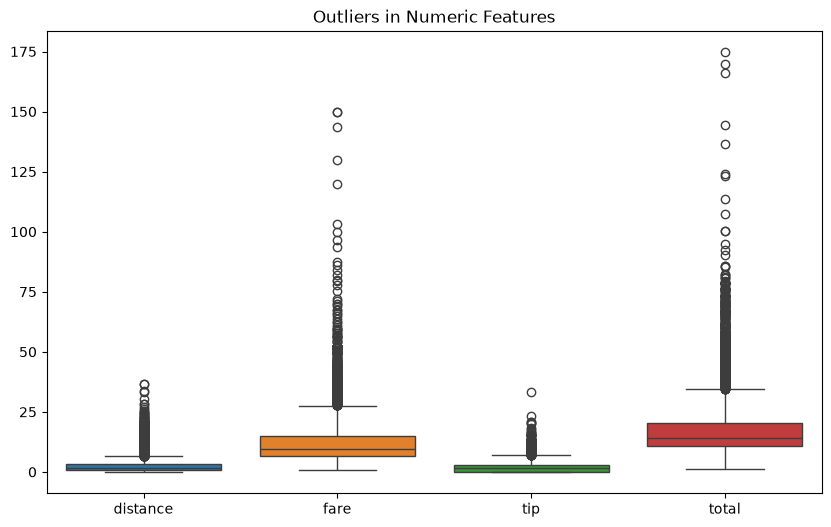

In [14]:
import matplotlib.pyplot as plt
# Numeric columns select karke subplot banana
numeric_cols = ['distance', 'fare', 'tip', 'total']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Outliers in Numeric Features")
plt.show()

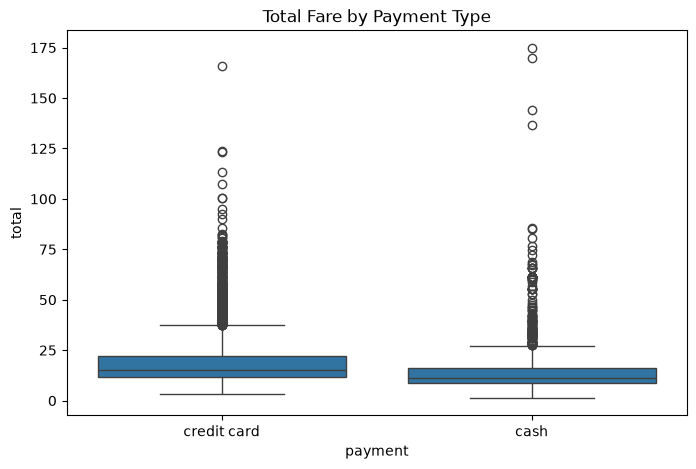

In [15]:
# Payment method ke hisaab se total amount ke outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x='payment', y='total', data=df)
plt.title("Total Fare by Payment Type")
plt.show()

In [16]:
q1 = df['fare'].quantile(0.25)
q3 = df['fare'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Fare ke outliers filter karna
outliers = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]
outliers[['fare', 'distance', 'total']].head()

,fare,distance,total
22,31.5,9.82,49.87
42,80.0,0.00,100.38
43,28.0,9.50,35.06
44,29.5,9.37,33.80
53,36.0,13.45,37.80


In [18]:
# Unnecessary aur leakage columns drop karna
cols_to_drop = ['pickup', 'dropoff', 'pickup_zone', 'dropoff_zone', 'tip', 'tolls', 'total']

df = df.drop(columns=cols_to_drop)
df.head()

,passengers,distance,fare,color,payment,pickup_borough,dropoff_borough
0,1,1.60,7.0,yellow,credit card,Manhattan,Manhattan
1,1,0.79,5.0,yellow,cash,Manhattan,Manhattan
2,1,1.37,7.5,yellow,credit card,Manhattan,Manhattan
3,1,7.70,27.0,yellow,credit card,Manhattan,Manhattan
4,3,2.16,9.0,yellow,credit card,Manhattan,Manhattan


In [20]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded_cols = ohe.fit_transform(df[['color', 'payment', 'pickup_borough', 'dropoff_borough']])

In [23]:
encoded_df = pd.DataFrame(
    encoded_cols,
    columns=ohe.get_feature_names_out(['color', 'payment', 'pickup_borough', 'dropoff_borough'])
)

# 2. Purane text columns ko hatakar naye encoded columns merge karein
df = df.drop(columns=['color', 'payment', 'pickup_borough', 'dropoff_borough']).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

df.head()

,passengers,distance,fare,color_yellow,payment_credit card,pickup_borough_Brooklyn,pickup_borough_Manhattan,pickup_borough_Queens,dropoff_borough_Brooklyn,dropoff_borough_Manhattan,dropoff_borough_Queens,dropoff_borough_Staten Island
0,1,1.60,7.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1,0.79,5.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,1.37,7.5,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1,7.70,27.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,3,2.16,9.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['passengers', 'distance','fare']
# Unhi existing columns ke upar scaled values overwrite karna
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()


,passengers,distance,fare,color_yellow,payment_credit card,pickup_borough_Brooklyn,pickup_borough_Manhattan,pickup_borough_Queens,dropoff_borough_Brooklyn,dropoff_borough_Manhattan,dropoff_borough_Queens,dropoff_borough_Staten Island
0,-0.448004,-0.372199,-0.527324,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.448004,-0.583821,-0.700471,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,-0.448004,-0.432289,-0.484038,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.448004,1.221502,1.204142,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.213575,-0.225892,-0.354178,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [26]:
x = df.drop(columns=['fare'])
y = df['fare']
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2, random_state = 42)
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

X_train shape: (5146, 11)
X_test shape: (1287, 11)


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
print(f"Random Forest Accuracy: {rf.score(x_test, y_test) * 100:.2f}%")

Random Forest Accuracy: 84.18%
